In [74]:
import pandas as pd
import matplotlib.pyplot as plt
movies = pd.read_csv('dataset/movies.csv')
ratings = pd.read_csv('dataset/ratings.csv')
tags = pd.read_csv('dataset/tags.csv')

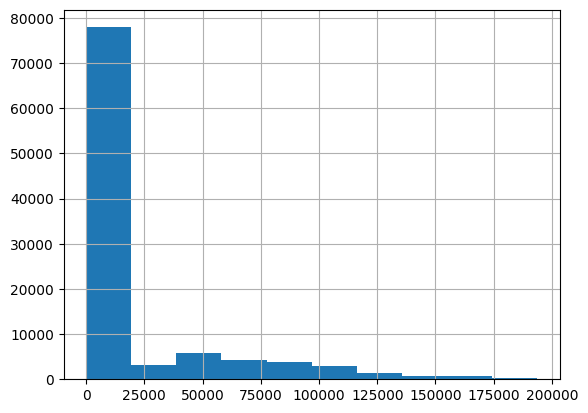

In [75]:
ratings['movieId'].hist()
plt.show()

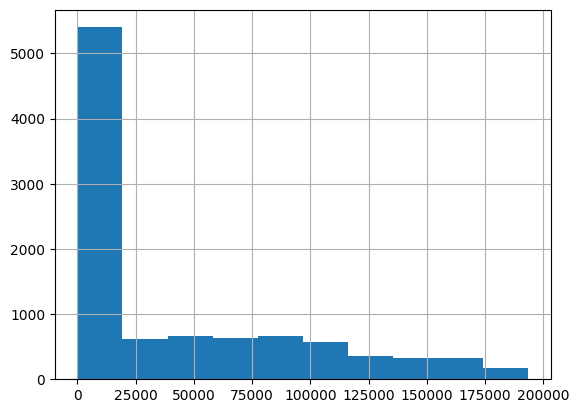

In [76]:
movies['movieId'].hist()
plt.show()

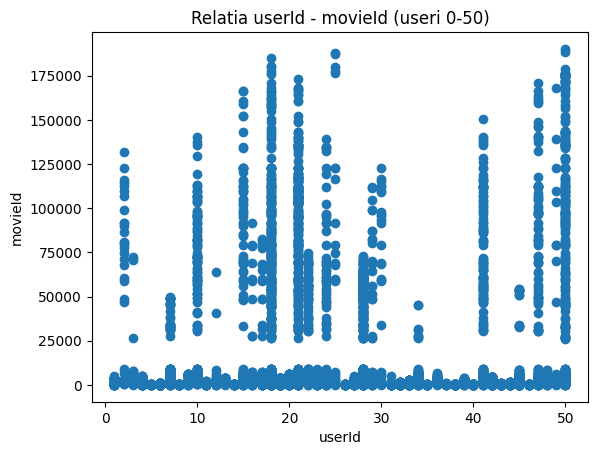

In [77]:
# relatie intre userId si movieId (doar userii 0-50)
subset = ratings[ratings['userId'] <= 50]
plt.scatter(subset['userId'], subset['movieId'])
plt.xlabel('userId')
plt.ylabel('movieId')
plt.title('Relatia userId - movieId (useri 0-50)')
plt.show()

In [78]:
# Tratarea valorilor lipsa
# nr filme care in entitate genres au valoarea "no genres listed"
print((movies['genres'] == '(no genres listed)').sum())
# inlocuim valoarea "no genres listed" cu un string gol
movies['genres'] = movies['genres'].replace('(no genres listed)', '')

34


In [79]:
movies['genres_list'] = movies['genres'].apply(
    lambda x: x.split('|') if x != '' else []
)

# Extragere an din titlu
movies['year'] = movies['title'].str.extract(r'\((\d{4})\)').astype(float)
movies['title'] = movies['title'].str.replace(r'\s*\(\d{4}\)', '', regex=True)

movies.head(5)

,movieId,title,genres,genres_list,year
0,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,"[Adventure, Animation, Children, Comedy, Fantasy]",1995.0
1,2,Jumanji,Adventure|Children|Fantasy,"[Adventure, Children, Fantasy]",1995.0
2,3,Grumpier Old Men,Comedy|Romance,"[Comedy, Romance]",1995.0
3,4,Waiting to Exhale,Comedy|Drama|Romance,"[Comedy, Drama, Romance]",1995.0
4,5,Father of the Bride Part II,Comedy,[Comedy],1995.0


In [80]:
#completarea manuala a anului pentru filmele fara an
year_map = {
    40697: 1993, 140956: 2018, 143410: 2015, 147250: 1980,
    149334: 2016, 156605: 2016, 162414: 2016, 167570: 2016,
    171495: 2019, 171631: 2017, 171749: 2006, 171891: 2017,
    176601: 2011
}
movies['year'] = movies['year'].fillna(movies['movieId'].map(year_map))

In [81]:
print("Analiza movies:")
display(movies.shape)
display(movies.head())
display(movies.info())
display(movies.describe())
display(movies.isnull().sum())
display(movies['year'].isnull().sum())

Analiza movies:


(9742, 5)

,movieId,title,genres,genres_list,year
0,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,"[Adventure, Animation, Children, Comedy, Fantasy]",1995.0
1,2,Jumanji,Adventure|Children|Fantasy,"[Adventure, Children, Fantasy]",1995.0
2,3,Grumpier Old Men,Comedy|Romance,"[Comedy, Romance]",1995.0
3,4,Waiting to Exhale,Comedy|Drama|Romance,"[Comedy, Drama, Romance]",1995.0
4,5,Father of the Bride Part II,Comedy,[Comedy],1995.0


<class 'pandas.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   movieId      9742 non-null   int64  
 1   title        9742 non-null   str    
 2   genres       9742 non-null   str    
 3   genres_list  9742 non-null   object 
 4   year         9742 non-null   float64
dtypes: float64(1), int64(1), object(1), str(2)
memory usage: 380.7+ KB


None

,movieId,year
count,9742.000000,9742.000000
mean,42200.353623,1994.635188
std,52160.494854,18.536694
min,1.000000,1902.000000
25%,3248.250000,1988.000000
50%,7300.000000,1999.000000
75%,76232.000000,2008.000000
max,193609.000000,2019.000000


movieId        0
title          0
genres         0
genres_list    0
year           0
dtype: int64

np.int64(0)

In [82]:
#Ratings : conversie timestamp -> datetime
ratings['timestamp'] = pd.to_datetime(ratings['timestamp'], unit='s')
print("Ratings - timestamp to datetime")
display(ratings[['userId', 'movieId', 'rating', 'timestamp']].head())

Ratings - timestamp to datetime


,userId,movieId,rating,timestamp
0,1,1,4.0,2000-07-30 18:45:03
1,1,3,4.0,2000-07-30 18:20:47
2,1,6,4.0,2000-07-30 18:37:04
3,1,47,5.0,2000-07-30 19:03:35
4,1,50,5.0,2000-07-30 18:48:51


In [83]:
print("\nAnaliza ratings:")
display(ratings.shape)
display(ratings.head())
display(ratings.info())
display(ratings.describe())
display(ratings.isnull().sum())


Analiza ratings:


(100836, 4)

,userId,movieId,rating,timestamp
0,1,1,4.0,2000-07-30 18:45:03
1,1,3,4.0,2000-07-30 18:20:47
2,1,6,4.0,2000-07-30 18:37:04
3,1,47,5.0,2000-07-30 19:03:35
4,1,50,5.0,2000-07-30 18:48:51


<class 'pandas.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype        
---  ------     --------------   -----        
 0   userId     100836 non-null  int64        
 1   movieId    100836 non-null  int64        
 2   rating     100836 non-null  float64      
 3   timestamp  100836 non-null  datetime64[s]
dtypes: datetime64[s](1), float64(1), int64(2)
memory usage: 3.1 MB


None

,userId,movieId,rating,timestamp
count,100836.000000,100836.000000,100836.000000,100836
mean,326.127564,19435.295718,3.501557,2008-03-19 17:01:27
min,1.000000,1.000000,0.500000,1996-03-29 18:36:55
25%,177.000000,1199.000000,3.000000,2002-04-18 09:57:46
50%,325.000000,2991.000000,3.500000,2007-08-02 20:31:02
75%,477.000000,8122.000000,4.000000,2015-07-04 07:15:44
max,610.000000,193609.000000,5.000000,2018-09-24 14:27:30
std,182.618491,35530.987199,1.042529,NaN


userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

In [84]:
# normalizare tag-uri(lowercase, whitespaces)
print("Exemple inainte de normalizare:")
display(tags['tag'].head(10))

tags['tag'] = tags['tag'].astype(str).str.lower().str.strip()

print("\nExemple dupa normalizare:")
display(tags['tag'].head(10))

Exemple inainte de normalizare:


0                funny
1      Highly quotable
2         will ferrell
3         Boxing story
4                  MMA
5            Tom Hardy
6                drugs
7    Leonardo DiCaprio
8      Martin Scorsese
9         way too long
Name: tag, dtype: str


Exemple dupa normalizare:


0                funny
1      highly quotable
2         will ferrell
3         boxing story
4                  mma
5            tom hardy
6                drugs
7    leonardo dicaprio
8      martin scorsese
9         way too long
Name: tag, dtype: str

In [85]:
# Tags : conversie timestamp -> datetime
tags['timestamp'] = pd.to_datetime(tags['timestamp'], unit='s')

print("\nTags - timestamp to datetime")
display(tags[['userId', 'movieId', 'tag', 'timestamp']].head())


Tags - timestamp to datetime


,userId,movieId,tag,timestamp
0,2,60756,funny,2015-10-24 19:29:54
1,2,60756,highly quotable,2015-10-24 19:29:56
2,2,60756,will ferrell,2015-10-24 19:29:52
3,2,89774,boxing story,2015-10-24 19:33:27
4,2,89774,mma,2015-10-24 19:33:20


In [86]:
print("\nAnaliza tags:")
display(tags.shape)
display(tags.head())
display(tags.info())
display(tags.describe())
display(tags.isnull().sum())
display(tags.duplicated().sum())


Analiza tags:


(3683, 4)

,userId,movieId,tag,timestamp
0,2,60756,funny,2015-10-24 19:29:54
1,2,60756,highly quotable,2015-10-24 19:29:56
2,2,60756,will ferrell,2015-10-24 19:29:52
3,2,89774,boxing story,2015-10-24 19:33:27
4,2,89774,mma,2015-10-24 19:33:20


<class 'pandas.DataFrame'>
RangeIndex: 3683 entries, 0 to 3682
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype        
---  ------     --------------  -----        
 0   userId     3683 non-null   int64        
 1   movieId    3683 non-null   int64        
 2   tag        3683 non-null   str          
 3   timestamp  3683 non-null   datetime64[s]
dtypes: datetime64[s](1), int64(2), str(1)
memory usage: 115.2 KB


None

,userId,movieId,timestamp
count,3683.000000,3683.000000,3683
mean,431.149335,27252.013576,2011-10-31 03:32:46
min,2.000000,1.000000,2006-01-13 19:09:12
25%,424.000000,1262.500000,2006-01-17 18:06:56
50%,474.000000,4454.000000,2010-03-29 03:16:04
75%,477.000000,39263.000000,2017-06-26 05:59:25
max,610.000000,193565.000000,2018-09-16 11:50:03
std,158.472553,43490.558803,NaN


userId       0
movieId      0
tag          0
timestamp    0
dtype: int64

np.int64(0)

In [87]:
# Cati utilizatori unici
display(ratings['userId'].nunique())
# Cate filme unice au primit rating
display(ratings['movieId'].nunique())
# Distributia rating-urilor
display(ratings['rating'].describe())
display(ratings['rating'].value_counts().sort_index())
# Cate rating-uri a dat fiecare utilizator
display(ratings.groupby('userId')['rating'].count().describe())
# Cate rating-uri are fiecare film
display(ratings.groupby('movieId')['rating'].count().describe())

610

9724

count    100836.000000
mean          3.501557
std           1.042529
min           0.500000
25%           3.000000
50%           3.500000
75%           4.000000
max           5.000000
Name: rating, dtype: float64

rating
0.5     1370
1.0     2811
1.5     1791
2.0     7551
2.5     5550
3.0    20047
3.5    13136
4.0    26818
4.5     8551
5.0    13211
Name: count, dtype: int64

count     610.000000
mean      165.304918
std       269.480584
min        20.000000
25%        35.000000
50%        70.500000
75%       168.000000
max      2698.000000
Name: rating, dtype: float64

count    9724.000000
mean       10.369807
std        22.401005
min         1.000000
25%         1.000000
50%         3.000000
75%         9.000000
max       329.000000
Name: rating, dtype: float64

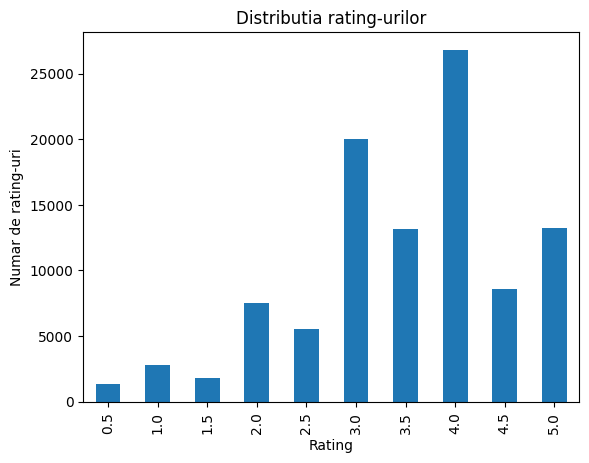

In [88]:
# Distributia rating-urilor (grafic)
ratings['rating'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Rating')
plt.ylabel('Numar de rating-uri')
plt.title('Distributia rating-urilor')
plt.show()

In [89]:
# numarul valorilor lipsa
display(movies.isnull().sum())
display(ratings.isnull().sum())
display(tags.isnull().sum())

# numarul duplicatelor
display(movies.drop(columns=['genres_list']).duplicated().sum())
display(ratings.duplicated().sum())
display(tags.duplicated().sum())

movieId        0
title          0
genres         0
genres_list    0
year           0
dtype: int64

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

userId       0
movieId      0
tag          0
timestamp    0
dtype: int64

np.int64(0)

np.int64(0)

np.int64(0)

In [90]:

# FEATURE ENGINEERING

In [91]:
# Features per film
movie_stats = ratings.groupby('movieId').agg(
    avg_rating=('rating', 'mean'),
    num_ratings=('rating', 'count')
).reset_index()

display(movie_stats.round(2).head(10))
display(movie_stats.describe())

# Ma ajuta strict sa vad cat de bun este un film bazat pe rating-urile
# oferite de useri. Daca un film are media rating-ului de 4.5 si 1000 de rating-uri, acesta pare sa fie un film foarte bun.

,movieId,avg_rating,num_ratings
0,1,3.92,215
1,2,3.43,110
2,3,3.26,52
3,4,2.36,7
4,5,3.07,49
5,6,3.95,102
6,7,3.19,54
7,8,2.88,8
8,9,3.12,16
9,10,3.50,132


,movieId,avg_rating,num_ratings
count,9724.000000,9724.000000,9724.000000
mean,42245.024373,3.262448,10.369807
std,52191.137320,0.869874,22.401005
min,1.000000,0.500000,1.000000
25%,3245.500000,2.800000,1.000000
50%,7300.000000,3.416667,3.000000
75%,76739.250000,3.911765,9.000000
max,193609.000000,5.000000,329.000000


In [92]:
# Features per user
user_stats = ratings.groupby('userId').agg(
    user_avg_rating=('rating', 'mean'),
    user_num_ratings=('rating', 'count')
).reset_index()

display(user_stats.round(2).head(10))
display(user_stats.describe())

# ajuta modelul sa inteleaga "presonalitatea" fiecarui user.
# Daca de exemplu user-ul 1 a avut media rating-ului de 4.37 si 232 rating-uri,
# acesta pare sa fie mai generos

,userId,user_avg_rating,user_num_ratings
0,1,4.37,232
1,2,3.95,29
2,3,2.44,39
3,4,3.56,216
4,5,3.64,44
5,6,3.49,314
6,7,3.23,152
7,8,3.57,47
8,9,3.26,46
9,10,3.28,140


,userId,user_avg_rating,user_num_ratings
count,610.000000,610.000000,610.000000
mean,305.500000,3.657222,165.304918
std,176.236111,0.480635,269.480584
min,1.000000,1.275000,20.000000
25%,153.250000,3.360000,35.000000
50%,305.500000,3.694385,70.500000
75%,457.750000,3.997500,168.000000
max,610.000000,5.000000,2698.000000


In [93]:
# Merge-ul tabelelor
movies = movies.merge(movie_stats, on='movieId', how='left')
ratings = ratings.merge(user_stats, on='userId', how='left')
df = ratings.merge(movies, on='movieId', how='left')
display(df.head())

,userId,movieId,rating,timestamp,user_avg_rating,user_num_ratings,title,genres,genres_list,year,avg_rating,num_ratings
0,1,1,4.0,2000-07-30 18:45:03,4.366379,232,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,"[Adventure, Animation, Children, Comedy, Fantasy]",1995.0,3.920930,215.0
1,1,3,4.0,2000-07-30 18:20:47,4.366379,232,Grumpier Old Men,Comedy|Romance,"[Comedy, Romance]",1995.0,3.259615,52.0
2,1,6,4.0,2000-07-30 18:37:04,4.366379,232,Heat,Action|Crime|Thriller,"[Action, Crime, Thriller]",1995.0,3.946078,102.0
3,1,47,5.0,2000-07-30 19:03:35,4.366379,232,Seven (a.k.a. Se7en),Mystery|Thriller,"[Mystery, Thriller]",1995.0,3.975369,203.0
4,1,50,5.0,2000-07-30 18:48:51,4.366379,232,"Usual Suspects, The",Crime|Mystery|Thriller,"[Crime, Mystery, Thriller]",1995.0,4.237745,204.0


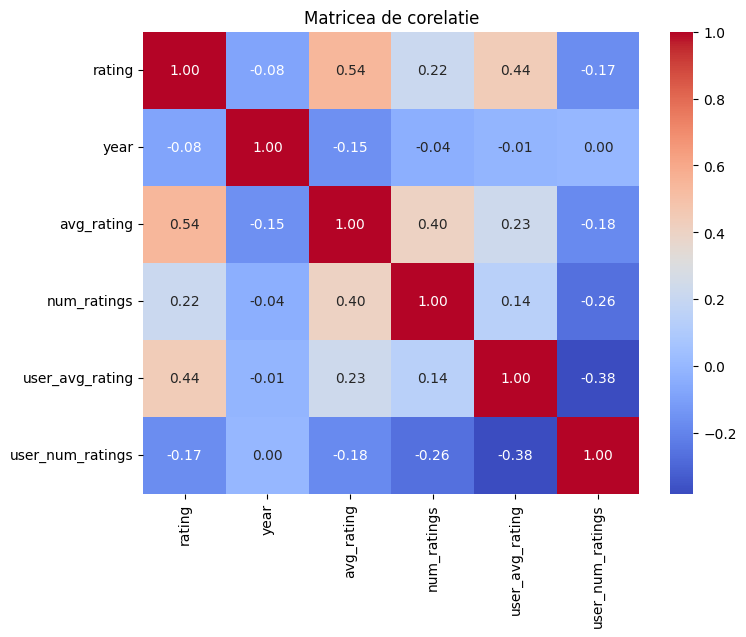

In [94]:
import seaborn as sns

numeric_cols = ['rating', 'year', 'avg_rating', 'num_ratings',
                'user_avg_rating', 'user_num_ratings']

plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matricea de corelatie')
plt.show()


In [95]:
# sa incerc si altceva inafara de k-nn
# sa incerc si random forest
# xg boost
# gru
# lstm 
# sa incerc cat de multe

Split train/test
Rating-urile vor fi impartite in felul urmator: 80% pentru antrenare si 20% pentru testare.

In [96]:
from sklearn.model_selection import train_test_split

# folosesc doar coloanele necesare pentru modelul colaborativ
ratings_cf = ratings[['userId', 'movieId', 'rating']].copy()

train_ratings, test_ratings = train_test_split(
    ratings_cf, test_size=0.2, random_state=42
)

print(f"Train: {train_ratings.shape[0]} rating-uri")
print(f"Test:  {test_ratings.shape[0]} rating-uri")
print(f"Useri unici (train): {train_ratings['userId'].nunique()}")
print(f"Filme unice (train): {train_ratings['movieId'].nunique()}")

Train: 80668 rating-uri
Test:  20168 rating-uri
Useri unici (train): 610
Filme unice (train): 8983


# K-NN - Item-Based

In [97]:
# Matrice user-movie pentru train
user_movie_matrix = train_ratings.pivot_table(
    index='movieId',
    columns='userId',
    values='rating',
    fill_value=0
)
print(f"Dimensiuni matrice: {user_movie_matrix.shape}")
print(f"(filme x useri)")
display(user_movie_matrix.head())

Dimensiuni matrice: (8983, 610)
(filme x useri)


userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
movieId,,,,,,,,,,,,,,,,,,,,,
1,4.0,0.0,0.0,0.0,0.0,0.0,4.5,0.0,0.0,0.0,...,0.0,0.0,4.0,3.0,4.0,2.5,0.0,2.5,3.0,5.0
2,0.0,0.0,0.0,0.0,0.0,4.0,0.0,4.0,0.0,0.0,...,0.0,4.0,0.0,5.0,3.5,0.0,0.0,2.0,0.0,0.0
3,4.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Convertire la matrice sparse pentru eficienta
from scipy.sparse import csr_matrix
matrix_sparse = csr_matrix(user_movie_matrix.values)

In [99]:
from sklearn.neighbors import NearestNeighbors

knn_model = NearestNeighbors(metric='cosine', algorithm='brute', n_neighbors=10)
knn_model.fit(matrix_sparse)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",10
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'brute'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'cosine'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [100]:
def recommend_similar_movies(movie_id, n=10):
    idx = user_movie_matrix.index.get_loc(movie_id)
    distances, indices = knn_model.kneighbors(matrix_sparse[idx], n_neighbors=n+1)
    similar_ids = user_movie_matrix.index[indices[0][1:]]  # exclud filmul insusi
    return movies[movies['movieId'].isin(similar_ids)][['title', 'genres']]

display(recommend_similar_movies(18))  # Toy Story

,title,genres
2687,Hamlet,Crime|Drama|Romance|Thriller
3690,Rare Birds,Comedy|Drama
3789,Human Nature,Comedy|Romance
3817,Deuces Wild,Drama
3833,"Believer, The",Drama
3859,Gangster No. 1,Action|Crime|Thriller
3976,Ballistic: Ecks vs. Sever,Action|Thriller
3989,Wasabi,Action|Comedy|Crime|Drama|Thriller
4906,Mad Dog and Glory,Comedy|Drama|Romance
7775,We Bought a Zoo,Comedy|Drama


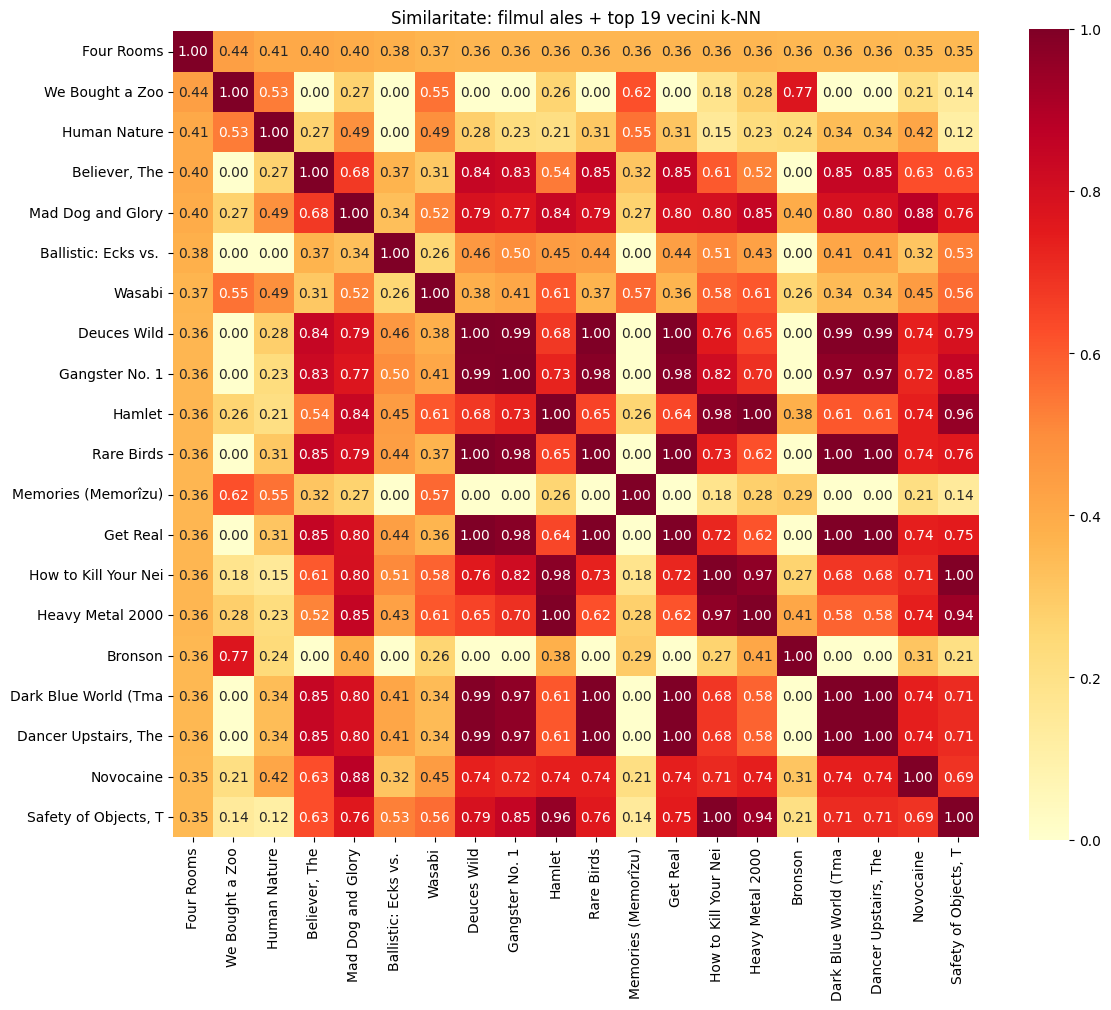

In [101]:
# Film ales + cei mai similari 19 vecini
movie_id = 18
idx = user_movie_matrix.index.get_loc(movie_id)
distances, indices = knn_model.kneighbors(matrix_sparse[idx], n_neighbors=20)

# Lista de movieIds (filmul + vecinii)
selected_ids = user_movie_matrix.index[indices[0]].tolist()

# Calcul imilaritate intre aceste 20 de filme
indices_in_matrix = [user_movie_matrix.index.get_loc(mid) for mid in selected_ids]
subset_matrix = matrix_sparse[indices_in_matrix]

from sklearn.metrics.pairwise import cosine_similarity
sim_matrix = cosine_similarity(subset_matrix)

titles_short = [movies[movies['movieId']==mid]['title'].values[0][:20] for mid in selected_ids]

plt.figure(figsize=(12, 10))
sns.heatmap(sim_matrix, xticklabels=titles_short, yticklabels=titles_short, 
            cmap='YlOrRd', annot=True, fmt='.2f', square=True)
plt.title(f'Similaritate: filmul ales + top 19 vecini k-NN')
plt.tight_layout()
plt.show()




# K-NN User-Based

In [ ]:
# Matrice user-movie pentru train
user_matrix = train_ratings.pivot_table(
    index='userId',
    columns='movieId',
    values='rating',
    fill_value=0
)
print(f"Dimensiuni matrice user-based: {user_matrix.shape}")
display(user_matrix.head())